# 🌗 The Mathematics of Seasonality & Trend

> **A math-first tour of how `mmm_framework` separates the *baseline* of a KPI into a periodic
> *seasonal* term and a slow-moving *trend* term.**
> This is notebook **03** in the math series. We derive the bases, plot every component, and verify
> each construction against the **actual framework code** with `assert` statements — so "the notebook
> runs clean" *means* "the math is right."

A marketing-mix model decomposes a KPI into media-driven contributions **plus** a *baseline* — the
sales the business would have made anyway. That baseline is rarely flat. It **breathes with the
calendar** (holidays, weather, paydays) and **drifts** over the years (category growth, distribution
gains, brand decay). If we do not give the model an explicit language for those two motions, they leak
into the media coefficients and corrupt every ROI estimate.

The framework provides two complementary *basis expansions* for the baseline — one for each motion:

| Motion | Basis | Framework function | Shape it draws |
|---|---|---|---|
| **Seasonal** (periodic) | **Fourier** harmonics | `create_fourier_features` | smooth, repeating |
| **Trend** (drift) | **B-spline** *or* **piecewise-linear** | `create_bspline_basis`, `create_piecewise_trend_matrix` | smooth / kinked |

The recurring idea is the same in both halves: build a fixed **design matrix** $\Phi$ of basis
functions, then let the Bayesian model learn a **coefficient vector** with a regularizing prior. The
*shape* lives in $\Phi$ (this notebook); the *amplitude* lives in the priors (which we describe but do
not sample). We close by fitting all three trend families to one synthetic series and watching the
linear model fail on a kink that the flexible bases catch.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

We pull the real transforms straight from the framework — every plot and assertion below calls these
exact functions, not re-implementations.

In [2]:
from mmm_framework.transforms import (
    create_fourier_features,
    create_bspline_basis,
    create_piecewise_trend_matrix,
)
print("loaded:",
      create_fourier_features.__name__,
      create_bspline_basis.__name__,
      create_piecewise_trend_matrix.__name__)

loaded: create_fourier_features create_bspline_basis create_piecewise_trend_matrix


# Part I — Seasonality via Fourier features

## The idea: any periodic shape is a sum of sines and cosines

A seasonal pattern with period $P$ (say $P=52$ weeks for a yearly cycle) is a *periodic* function:
$g(t+P) = g(t)$. The **Fourier theorem** says any reasonable periodic function can be written as a sum
of harmonics — sines and cosines whose frequencies are integer multiples of the fundamental $1/P$:

$$
g(t) \;=\; \sum_{k=1}^{\infty}
\Big[\, a_k \sin\!\Big(\tfrac{2\pi k\, t}{P}\Big)
      + b_k \cos\!\Big(\tfrac{2\pi k\, t}{P}\Big) \,\Big].
$$

Truncating the sum at a finite **order** $K$ gives a smooth approximation that gets sharper as $K$
grows. That truncation is exactly what `create_fourier_features(t, period, order)` builds: a design
matrix $\Phi \in \mathbb{R}^{T \times 2K}$ whose columns are the harmonics, **interleaved** as

$$
\Phi(t) \;=\;
\big[\,
\underbrace{\sin\tfrac{2\pi t}{P}}_{k=1},\;
\underbrace{\cos\tfrac{2\pi t}{P}}_{k=1},\;
\underbrace{\sin\tfrac{4\pi t}{P}}_{k=2},\;
\underbrace{\cos\tfrac{4\pi t}{P}}_{k=2},\;
\dots,\;
\sin\tfrac{2\pi K t}{P},\;
\cos\tfrac{2\pi K t}{P}
\,\big].
$$

Note the column order: it is $[\sin_1, \cos_1, \sin_2, \cos_2, \dots]$ — sine *then* cosine within each
harmonic, **not** all sines followed by all cosines. The harmonic-$k$ pair has shape $(T, 2)$, so the
full matrix is $(T, 2K)$. In the model the seasonal coefficients carry a tight prior,

$$
\big[a_k, b_k\big] \sim \mathcal{N}(0,\, 0.3^2),
\qquad
\text{seasonality}_t \;=\; \Phi(t)\, \boldsymbol{\theta},
$$

i.e. `seasonality = features @ coef`. The $\mathcal{N}(0, 0.3)$ prior keeps each harmonic's amplitude
modest, so high orders cannot run away — the regularization that tames the overfitting we demonstrate
below.

### Why *both* sine and cosine?

A single sine $\sin(2\pi k t / P)$ is pinned to a fixed *phase* (zero-crossing at $t=0$). Real seasonal
peaks land wherever the calendar puts them. The identity

$$
A\sin(\omega t + \varphi) \;=\; \underbrace{A\cos\varphi}_{a}\,\sin(\omega t)
                                 + \underbrace{A\sin\varphi}_{b}\,\cos(\omega t)
$$

shows that a sine/cosine **pair** spans every amplitude $A$ and every phase $\varphi$ at that frequency.
That is why the basis always comes in pairs: two columns per harmonic buy arbitrary phase for free.

In [3]:
# Build seasonality on INTEGER weeks so the period is exact -> periodicity is testable.
P = 52                       # yearly cycle, weekly data
t_weeks = np.arange(2 * P)   # two full years, integer weeks
print("t_weeks:", t_weeks[:6], "...", t_weeks[-3:])

# Order-3 design matrix: 3 harmonics -> 6 columns, interleaved [sin1,cos1,sin2,cos2,sin3,cos3].
order = 3
Phi = create_fourier_features(t_weeks.astype(float), period=float(P), order=order)
print("Phi shape:", Phi.shape, " (expect (104, 6))")

# VERIFY: shape is (len(t), 2*order), and columns ARE the interleaved sin/cos harmonics.
assert Phi.shape == (len(t_weeks), 2 * order), "shape must be (T, 2*order)"
for k in range(1, order + 1):
    expect_sin = np.sin(2 * np.pi * k * t_weeks / P)
    expect_cos = np.cos(2 * np.pi * k * t_weeks / P)
    assert np.allclose(Phi[:, 2 * (k - 1)],     expect_sin, atol=1e-12)
    assert np.allclose(Phi[:, 2 * (k - 1) + 1], expect_cos, atol=1e-12)
print("✓ shape == (len(t), 2*order)")
print("✓ column 2(k-1) == sin harmonic k, column 2(k-1)+1 == cos harmonic k")

t_weeks: [0 1 2 3 4 5] ... [101 102 103]
Phi shape: (104, 6)  (expect (104, 6))
✓ shape == (len(t), 2*order)
✓ column 2(k-1) == sin harmonic k, column 2(k-1)+1 == cos harmonic k


### Plot: the individual harmonics

Each harmonic $k$ completes $k$ full cycles per period. Harmonic 1 is the slow, fundamental swing;
higher harmonics oscillate faster and let the basis carve out sharper features. Below are the sine
columns of the first three harmonics over one year.

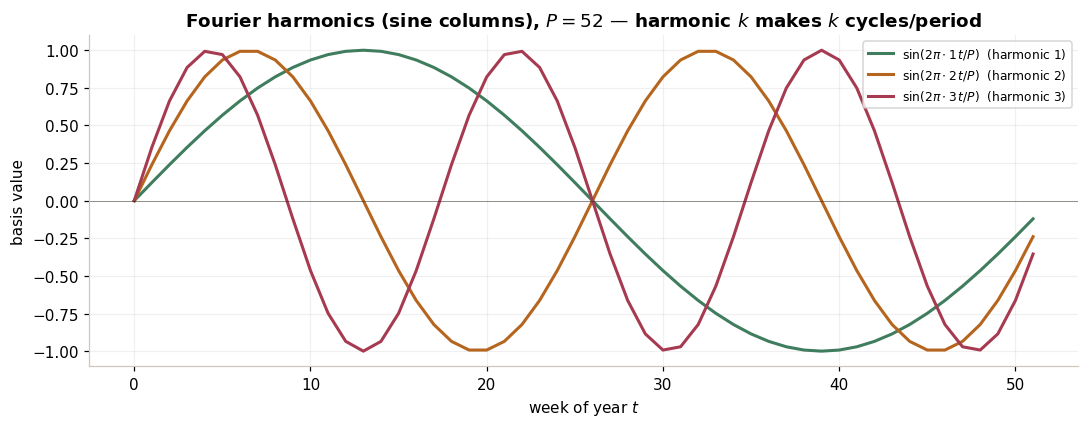

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
cols = [PALETTE["leaf"], ACCENT, PALETTE["berry"]]
for k, col in zip(range(1, order + 1), cols):
    ax.plot(t_weeks[:P], Phi[:P, 2 * (k - 1)], color=col, lw=2,
            label=rf"$\sin(2\pi\cdot{k}\,t/P)$  (harmonic {k})")
ax.axhline(0, color=INK, lw=0.6, alpha=0.5)
ax.set_xlabel("week of year $t$"); ax.set_ylabel("basis value")
ax.set_title(f"Fourier harmonics (sine columns), $P={P}$ — harmonic $k$ makes $k$ cycles/period")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

### Periodicity: the features repeat exactly every $P$

Because every column is a sine or cosine of $2\pi k t / P$, shifting $t$ by one full period $P$ leaves
the design matrix unchanged: $\Phi(t+P) = \Phi(t)$. With **integer** weeks and an **integer** period
this holds to floating-point precision — the framework docstring's `features[0] == features[52]`
promise, generalized to the whole matrix.

In [5]:
# VERIFY periodicity: the entire matrix repeats with period P (integer t, integer P).
# Row i and row i+P must coincide for every overlapping i.
assert np.allclose(Phi[:P], Phi[P:2 * P], atol=1e-9), "features must repeat every P"
# Spot-check the docstring's exact claim.
assert np.allclose(Phi[0], Phi[P], atol=1e-9)
print("✓ Phi[i] == Phi[i+P] for all i  (period =", P, ")")
print("✓ docstring claim features[0] == features[52]:",
      np.allclose(Phi[0], Phi[P]))

✓ Phi[i] == Phi[i+P] for all i  (period = 52 )
✓ docstring claim features[0] == features[52]: True


## Reconstruction: more harmonics, sharper fit

To see *what order buys you*, take a deliberately non-sinusoidal target — a periodic "spiky holiday"
bump riding on a gentle wave — and reconstruct it by **least squares** at increasing order. For a fixed
order $K$ we solve

$$
\hat{\boldsymbol\theta}_K
= \arg\min_{\boldsymbol\theta}
\big\| \, g - \Phi_K\,\boldsymbol\theta \, \big\|_2^2 ,
\qquad
\hat g_K = \Phi_K\,\hat{\boldsymbol\theta}_K .
$$

Fourier columns have **zero mean**, so they cannot represent a constant offset; we add an intercept
column $\mathbf{1}$ to the design (the model handles the baseline level separately). As $K$ rises the
residual $\|g-\hat g_K\|$ **monotonically decreases** — more basis vectors can only help the in-sample
least-squares fit. The question is whether the extra wiggles are *signal* or *overfit*.

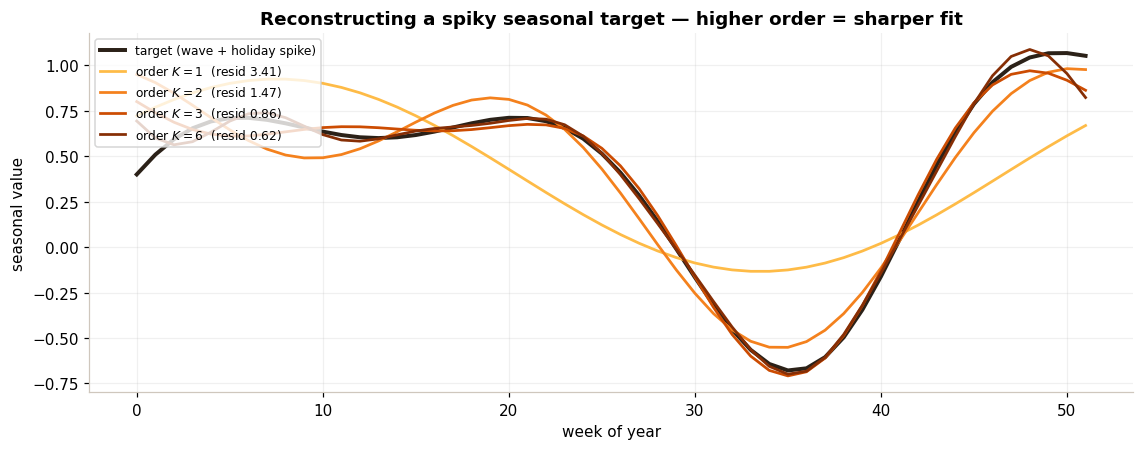

residual ||g - g_hat|| by order: {1: np.float64(3.408), 2: np.float64(1.473), 3: np.float64(0.858), 6: np.float64(0.616)}


In [6]:
# A periodic target that is NOT a single sinusoid: a smooth wave plus a sharp seasonal spike.
def seasonal_target(t, P):
    phase = 2 * np.pi * t / P
    wave = np.sin(phase) + 0.4 * np.cos(2 * phase)          # smooth part (orders 1-2)
    # sharp recurring "holiday" bump centered near week 0.85*P each year
    frac = (t % P) / P
    spike = 1.6 * np.exp(-((frac - 0.85) ** 2) / (2 * 0.012))
    return wave + spike

g = seasonal_target(t_weeks.astype(float), P)

def fit_fourier(t, P, order, target):
    F = create_fourier_features(t.astype(float), float(P), order)
    X = np.column_stack([np.ones(len(t)), F])               # intercept + harmonics
    theta, *_ = np.linalg.lstsq(X, target, rcond=None)
    return X @ theta

orders = [1, 2, 3, 6]
fits = {K: fit_fourier(t_weeks, P, K, g) for K in orders}
resid = {K: np.linalg.norm(g - fits[K]) for K in orders}

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.plot(t_weeks[:P], g[:P], color=INK, lw=2.6, label="target (wave + holiday spike)")
shades = plt.cm.YlOrBr(np.linspace(0.4, 0.92, len(orders)))
for K, col in zip(orders, shades):
    ax.plot(t_weeks[:P], fits[K][:P], color=col, lw=1.8,
            label=rf"order $K={K}$  (resid {resid[K]:.2f})")
ax.set_xlabel("week of year"); ax.set_ylabel("seasonal value")
ax.set_title("Reconstructing a spiky seasonal target — higher order = sharper fit")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print("residual ||g - g_hat|| by order:", {K: round(resid[K], 3) for K in orders})

In [7]:
# VERIFY reconstruction: residual decreases monotonically with order, and the
# high-order fit tracks the target with high correlation (it is the PLOTTED claim).
res_seq = [resid[K] for K in orders]
assert all(res_seq[i] >= res_seq[i + 1] - 1e-9 for i in range(len(res_seq) - 1)), \
    "more harmonics must not increase the least-squares residual"
corr_K6 = np.corrcoef(g, fits[6])[0, 1]
assert corr_K6 > 0.97, f"order-6 reconstruction should track target, corr={corr_K6:.3f}"
print("✓ residual is monotonically non-increasing in order:",
      [round(r, 3) for r in res_seq])
print(f"✓ order-6 reconstruction correlation with target = {corr_K6:.4f} (> 0.97)")

✓ residual is monotonically non-increasing in order: [np.float64(3.408), np.float64(1.473), np.float64(0.858), np.float64(0.616)]
✓ order-6 reconstruction correlation with target = 0.9927 (> 0.97)


## Underfit vs overfit: order is a bias–variance dial

Lower the data into the *noisy* regime and the trade-off bites. We add Gaussian noise to the seasonal
signal, then fit at a **low** order (underfit — too rigid to follow the spike) and a **very high** order
(overfit — chasing noise). The truth is order $\approx 3$–$4$. The high-order curve has the smaller
*training* residual yet is visibly worse where it matters, wiggling between data points. This is why the
framework pairs a modest default order with the shrinking $\mathcal{N}(0, 0.3)$ prior: regularization,
not raw flexibility, controls variance.

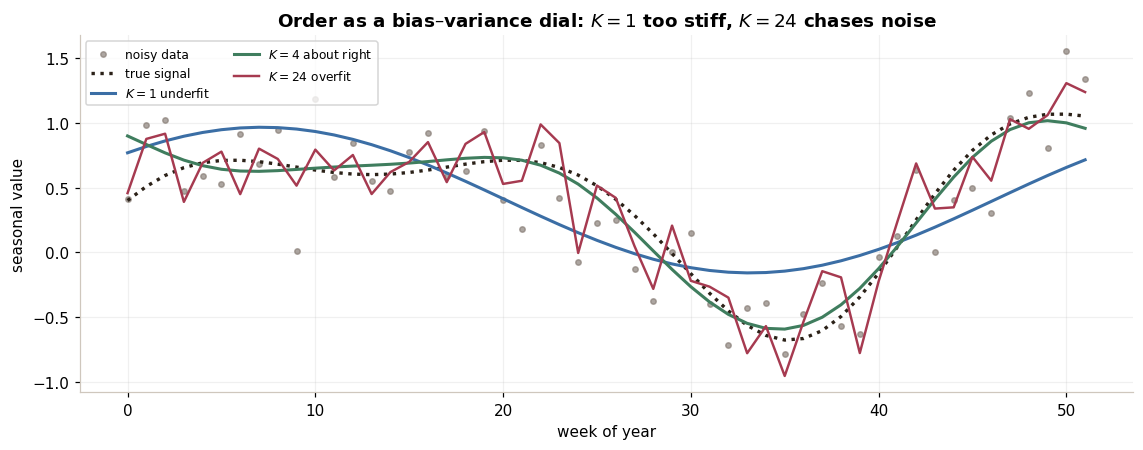

In [8]:
rng = np.random.default_rng(11)
g_noisy = g + rng.normal(0, 0.35, size=g.size)

fit_lo = fit_fourier(t_weeks, P, 1, g_noisy)    # underfit: one harmonic can't see the spike
fit_ok = fit_fourier(t_weeks, P, 4, g_noisy)    # about right
fit_hi = fit_fourier(t_weeks, P, 24, g_noisy)   # overfit: 24 harmonics chase the noise

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.plot(t_weeks[:P], g_noisy[:P], "o", ms=3.5, color=MUTED, alpha=0.7, label="noisy data")
ax.plot(t_weeks[:P], g[:P], color=INK, lw=2.2, ls=":", label="true signal")
ax.plot(t_weeks[:P], fit_lo[:P], color=PALETTE["sky"], lw=2,  label=r"$K=1$ underfit")
ax.plot(t_weeks[:P], fit_ok[:P], color=PALETTE["leaf"], lw=2, label=r"$K=4$ about right")
ax.plot(t_weeks[:P], fit_hi[:P], color=PALETTE["berry"], lw=1.6, label=r"$K=24$ overfit")
ax.set_xlabel("week of year"); ax.set_ylabel("seasonal value")
ax.set_title("Order as a bias–variance dial: $K=1$ too stiff, $K=24$ chases noise")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [9]:
# VERIFY the bias-variance story numerically:
#  (1) training residual still shrinks with order (lstsq monotonicity),
#  (2) but the overfit fit is FARTHER from the TRUE (noiseless) signal than the moderate fit.
r1  = np.linalg.norm(g_noisy - fit_lo)
r4  = np.linalg.norm(g_noisy - fit_ok)
r24 = np.linalg.norm(g_noisy - fit_hi)
assert r1 >= r4 >= r24 - 1e-9, "training residual must be non-increasing in order"
err_ok = np.linalg.norm(g - fit_ok)     # distance to the TRUTH, not the noisy data
err_hi = np.linalg.norm(g - fit_hi)
assert err_hi > err_ok, "overfit (K=24) should be worse vs the true signal than K=4"
print(f"✓ training residual non-increasing: K=1 {r1:.2f} >= K=4 {r4:.2f} >= K=24 {r24:.2f}")
print(f"✓ vs TRUTH: K=4 err {err_ok:.2f} < K=24 err {err_hi:.2f}  -> high order overfits")

✓ training residual non-increasing: K=1 4.38 >= K=4 3.19 >= K=24 2.23
✓ vs TRUTH: K=4 err 1.11 < K=24 err 2.31  -> high order overfits


# Part II — Trend

Seasonality is *periodic*; trend is the **non-periodic drift** of the baseline — the slow climb or
decline that does not repeat. The framework offers three families, ordered by flexibility:

1. **Linear** — a single slope. The framework default; the model variable is `trend_slope` with a tight
   $\mathcal{N}(0, 0.5)$ prior. One number, maximal shrinkage, zero ability to bend.
2. **Piecewise-linear (Prophet-style)** — a linear trend whose *slope* can change at a handful of
   changepoints. Built by `create_piecewise_trend_matrix`.
3. **B-spline** — a smooth, locally-supported polynomial basis. Built by `create_bspline_basis`.

A fourth option, a **Gaussian-process / Hilbert-space** trend, is also available in the framework for a
fully nonparametric drift; we mention it but do not exercise it here. All of these are defined on a
**rescaled time axis** $t \in [0, 1]$ — that is the convention both trend functions assume, and it is
*different* from the integer weeks we used for seasonality.

In [10]:
# Trend lives on a RESCALED axis t in [0, 1] (NOT integer weeks).
N = 160
t = np.linspace(0, 1, N)
print("t:", t[:3], "...", t[-3:], " (rescaled to [0,1])")

t: [0.         0.00628931 0.01257862] ... [0.98742138 0.99371069 1.        ]  (rescaled to [0,1])


## Trend family 1 — Linear

The simplest baseline drift is a straight line,

$$
\text{trend}(t) \;=\; k + m\,t,
\qquad m \sim \mathcal{N}(0,\, 0.5),
$$

where $m$ is the framework's `trend_slope`. The $\mathcal{N}(0,0.5)$ prior is deliberately tight: a
straight line is the *least* flexible trend, so it can only express monotone growth or decay and is
heavily regularized. It is the right default when you have little data or strong priors that the
baseline is roughly stable — but it cannot bend around a structural break, which motivates the next two
families.

## Trend family 2 — Piecewise linear (Prophet-style)

`create_piecewise_trend_matrix(t, n_changepoints, changepoint_range=0.8)` returns a pair $(s, A)$:

- $s \in \mathbb{R}^{C}$ — the **changepoint locations**, evenly spaced inside the first
  $\texttt{changepoint\_range}$ of the time axis (default $0.8$, so no changepoints in the last 20% —
  this guards against overfitting the most recent, most influential observations).
- $A \in \{0,1\}^{T \times C}$ — a **step indicator matrix**,

$$
A_{t,j} \;=\;
\begin{cases}
1 & \text{if } t \ge s_j,\\[2pt]
0 & \text{otherwise.}
\end{cases}
$$

The Prophet **piecewise-linear** trend uses $A$ not as a level shifter but as a *switch on slope changes*.
Write a **base growth rate** $k$ (the slope before any changepoint) and an **offset** $m$ (the level at
$t=0$), and let each $\delta_j$ be a **change in slope** that turns on at $s_j$. Then the cumulative slope
at time $t$ is $k + (A\boldsymbol\delta)_t$ — the base rate plus every slope change already activated — and
the trend is

$$
\text{trend}(t)
\;=\; \big(\,\underbrace{k}_{\text{base rate}} + (A\,\boldsymbol\delta)_t\,\big)\, t
\;+\; \big(\,\underbrace{m}_{\text{offset}} + (A\,\boldsymbol\gamma)_t\,\big),
\qquad
\gamma_j \;=\; -\,s_j\,\delta_j .
$$

> **Naming note.** In this piecewise block $k$ is the *slope/growth rate* and $m$ is the *offset*,
> matching `base.py` (`trend_k`, `trend_m`). This is the opposite of the linear section two cells up,
> where the single slope was written $m$. Same letters, different roles — read them per section.

**Why the cumulative slope multiplies $t$ — and what $\boldsymbol\gamma$ is for.** The whole point is that
$\delta_j$ changes the **slope**, not the level. That only happens if $A\boldsymbol\delta$ enters as a
*coefficient on $t$*. Multiplying the slope by $t$, however, would make the trend **jump** at each
changepoint (the new slope is suddenly applied to the whole elapsed time, including the part before $s_j$).
The offset correction $\gamma_j = -s_j\,\delta_j$ exactly cancels that jump: expanding one active
changepoint, $\delta_j\, t + \gamma_j = \delta_j\,(t - s_j)$, which is **zero at $t=s_j$** and grows only
afterward — the cumulative *ramp* basis $(t-s_j)_{+}$. So the trend stays **continuous** and merely
*kinks* (its slope changes) at each $s_j$.

**The bug that was fixed.** Using $A\boldsymbol\delta$ as a bare additive term *without* the $\cdot\,t$ —
i.e. $k + m t + A\boldsymbol\delta$ — would make $A\boldsymbol\delta$ a sum of step functions: **piecewise
constant level shifts**, with the slope never changing. That was a previous bug. The tell is the lone
$\boldsymbol\gamma$ continuity term: it is *meaningless under level shifts* (there is no slope jump to
cancel) and only makes sense when slope changes were intended. `base.py`'s `_build_piecewise_trend` now
implements exactly the slope-change formula above. Sparse priors on $\boldsymbol\delta$ (a Laplace prior,
`trend_delta`) keep most changepoints at zero so the model "spends" a slope bend only where the data
demand one.

In [11]:
C = 8
s, A = create_piecewise_trend_matrix(t, n_changepoints=C, changepoint_range=0.8)
print("changepoint locations s:", np.round(s, 3))
print("A shape:", A.shape, " (expect (160, 8))")

# VERIFY: A is a 0/1 step matrix and A[t,j] == (t >= s[j]); changepoints stay within range.
assert A.shape == (N, C)
assert set(np.unique(A)).issubset({0.0, 1.0}), "A must be binary 0/1"
for j, sj in enumerate(s):
    assert np.array_equal(A[:, j], (t >= sj).astype(float)), f"column {j} != indicator"
assert s.max() <= 0.8 + 1e-9, "changepoints must lie within changepoint_range"
print("✓ A takes only values {0, 1}")
print("✓ A[:, j] == (t >= s[j]) for every changepoint j")
print("✓ all changepoints within changepoint_range = 0.8")

changepoint locations s: [0.089 0.178 0.267 0.356 0.444 0.533 0.622 0.711]
A shape: (160, 8)  (expect (160, 8))
✓ A takes only values {0, 1}
✓ A[:, j] == (t >= s[j]) for every changepoint j
✓ all changepoints within changepoint_range = 0.8


### The design matrix as a heatmap

The step structure is clearest as an image: each column "turns on" (white) at its changepoint $s_j$ and
stays on. The staircase of activation fronts marching left-to-right *is* the piecewise basis.

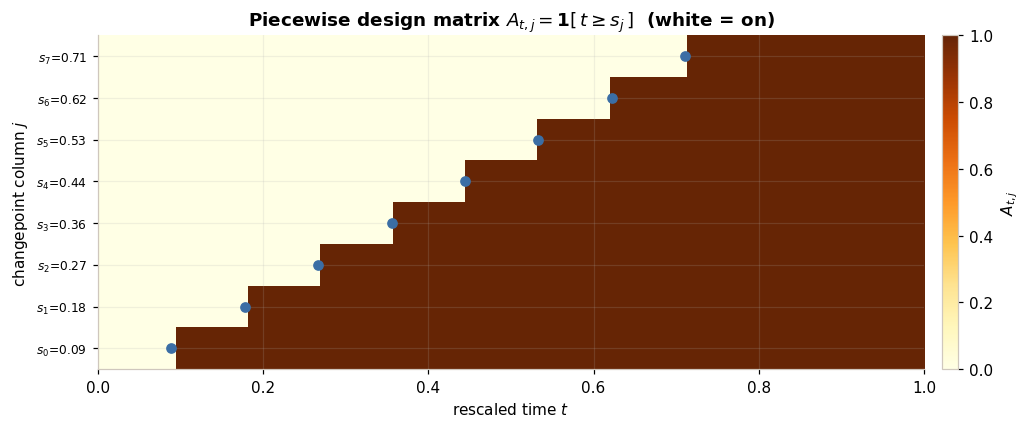

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4))
im = ax.imshow(A.T, aspect="auto", origin="lower", cmap="YlOrBr",
               extent=[0, 1, -0.5, C - 0.5], interpolation="nearest")
for j, sj in enumerate(s):
    ax.plot(sj, j, "o", color=PALETTE["sky"], ms=6)   # mark each changepoint
ax.set_yticks(range(C))
ax.set_yticklabels([rf"$s_{{{j}}}$={sj:.2f}" for j, sj in enumerate(s)], fontsize=8)
ax.set_xlabel("rescaled time $t$"); ax.set_ylabel("changepoint column $j$")
ax.set_title(r"Piecewise design matrix $A_{t,j}=\mathbf{1}[\,t\geq s_j\,]$  (white = on)")
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cbar.set_label("$A_{t,j}$")
plt.tight_layout(); plt.show()

### A piecewise trend in action

To see what the basis *produces*, fix a base growth rate $k$, an offset $m$, and a sparse slope-change
vector $\boldsymbol\delta$ (only a few changepoints active, with **differing signs**), set
$\gamma_j = -s_j\,\delta_j$, and evaluate

$$
\text{slope}(t) = k + (A\boldsymbol\delta)_t,
\qquad
\text{trend}(t) = \text{slope}(t)\,t + \big(m + (A\boldsymbol\gamma)_t\big).
$$

The trend is **continuous** — no level jumps — but it visibly **kinks** at each active changepoint, bending
to a steeper or shallower line. The second panel makes the mechanism literal: the instantaneous slope
$k+(A\boldsymbol\delta)_t$ is a **step function** that jumps by exactly $\delta_j$ at each $s_j$.

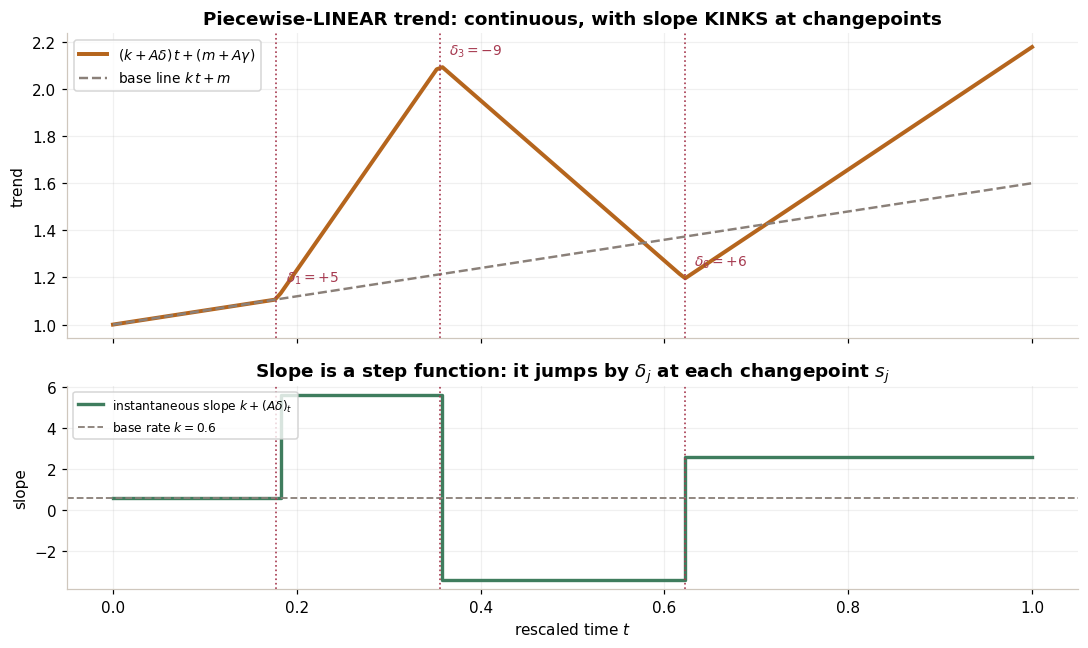

✓ trend == cumulative ramp k*t+m+sum delta_j*(t-s_j)+ to 1e-12  (continuous, slope-changing)
✓ no level jumps: max single-step 0.0352 << range 1.18
✓ slope after last changepoint == k + sum(delta) = 2.600
✓ slope jumps by delta_j at each changepoint: {1: 5.0, 3: -9.0, 6: 6.0}
✓ A is a 0/1 step indicator with A[t,j] == (t >= s[j])
   -> SLOPE changes (kinks), NOT level shifts.


In [13]:
k_base, m_base = 0.6, 1.0          # k = base growth RATE (slope), m = offset (level at t=0)
delta = np.zeros(C)
delta[1] = 5.0     # slope steepens sharply at s[1]
delta[3] = -9.0    # slope reverses (declines) after s[3]
delta[6] = 6.0     # slope climbs again after s[6]
active = [1, 3, 6]

gamma = -s * delta                 # continuity correction: gamma_j = -s_j * delta_j
slope = k_base + A @ delta         # cumulative slope (step function in t)
trend_pw = slope * t + (m_base + A @ gamma)

fig, (axT, axS) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

axT.plot(t, trend_pw, color=ACCENT, lw=2.6, label=r"$(k+A\delta)\,t + (m+A\gamma)$")
axT.plot(t, k_base * t + m_base, color=MUTED, lw=1.6, ls="--", label=r"base line $k\,t+m$")
for j in active:
    axT.axvline(s[j], color=PALETTE["berry"], lw=1.1, ls=":")
    axT.annotate(rf"$\delta_{{{j}}}={delta[j]:+.0f}$",
                 (s[j], trend_pw[np.searchsorted(t, s[j])]),
                 textcoords="offset points", xytext=(6, 8), fontsize=9, color=PALETTE["berry"])
axT.set_ylabel("trend")
axT.set_title("Piecewise-LINEAR trend: continuous, with slope KINKS at changepoints")
axT.legend(loc="upper left", fontsize=9)

axS.step(t, slope, where="post", color=PALETTE["leaf"], lw=2.2,
         label=r"instantaneous slope $k+(A\delta)_t$")
axS.axhline(k_base, color=MUTED, lw=1.2, ls="--", label=rf"base rate $k={k_base}$")
for j in active:
    axS.axvline(s[j], color=PALETTE["berry"], lw=1.1, ls=":")
axS.set_xlabel("rescaled time $t$"); axS.set_ylabel("slope")
axS.set_title(r"Slope is a step function: it jumps by $\delta_j$ at each changepoint $s_j$")
axS.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

# VERIFY slope-change (not level-shift):
# (1) the trend is CONTINUOUS and slope-changing -- it equals the cumulative RAMP basis
#     k*t + m + sum_j delta_j * (t - s_j)+ to machine precision. This single identity proves
#     BOTH properties at once: (t-s_j)+ is 0 at s_j (no level jump) and bends the slope after.
#     [Algebra: (k+A.delta)*t + (m+A.gamma) with gamma=-s*delta expands to this ramp sum.]
dt = t[1] - t[0]
ramp = k_base * t + m_base + sum(delta[j] * np.maximum(t - s[j], 0.0) for j in range(C))
assert np.allclose(trend_pw, ramp, atol=1e-12), \
    "trend must equal the continuous (t - s_j)+ ramp form (slope-change, not level-shift)"
# Visual backstop: the largest single-step rise is tiny vs the trend's range (no level jump);
# it is just the steepest segment's normal grid rise, NOT a changepoint discontinuity.
rng_trend = trend_pw.max() - trend_pw.min()
max_step = np.abs(np.diff(trend_pw)).max()
assert max_step < 0.05 * rng_trend, \
    f"no level jumps: max step {max_step:.4f} vs range {rng_trend:.4f}"

# (2) use the EXACT slope array for the slope claims (diff(trend)/dt would smear across grid).
#     Slope AFTER the last changepoint equals k + sum(delta).
assert np.isclose(slope[-1], k_base + delta.sum(), atol=1e-9), "final slope must be k + sum(delta)"

# (3) the slope jumps by exactly delta_j across each active changepoint s_j.
for j in active:
    i = np.searchsorted(t, s[j])                  # first index with t >= s_j
    jump = slope[i] - slope[i - 1]
    assert np.isclose(jump, delta[j], atol=1e-9), f"slope jump at s[{j}] != delta[{j}]"

# (4) A is a 0/1 step indicator with A[t,j] == (t >= s[j]).
assert set(np.unique(A)).issubset({0.0, 1.0})
for j, sj in enumerate(s):
    assert np.array_equal(A[:, j], (t >= sj).astype(float))

print(f"✓ trend == cumulative ramp k*t+m+sum delta_j*(t-s_j)+ to 1e-12  (continuous, slope-changing)")
print(f"✓ no level jumps: max single-step {max_step:.4f} << range {rng_trend:.2f}")
print(f"✓ slope after last changepoint == k + sum(delta) = {k_base + delta.sum():.3f}")
print("✓ slope jumps by delta_j at each changepoint:",
      {j: round(float(delta[j]), 1) for j in active})
print("✓ A is a 0/1 step indicator with A[t,j] == (t >= s[j])")
print("   -> SLOPE changes (kinks), NOT level shifts.")

## Trend family 3 — B-spline basis

`create_bspline_basis(t, n_knots, degree=3)` returns a matrix $B \in \mathbb{R}^{T \times M}$ with
$M = \texttt{n\_knots} + \texttt{degree} + 1$ columns. Each column is a **B-spline** — a piecewise
polynomial of the given degree (default cubic) that is **non-zero only over a few adjacent knot
intervals**. That *local support* is what makes splines well-behaved: moving one coefficient nudges the
curve locally instead of globally.

Two structural properties matter, both guaranteed by the construction:

**Partition of unity.** At every $t$ the basis functions sum to one,

$$
\sum_{j=1}^{M} B_j(t) \;=\; 1 \qquad \text{for all } t \in [0,1].
$$

So a *constant* coefficient vector reproduces a constant function, and the basis never injects or
removes "mass" — it only redistributes it. This is the spline analogue of the normalized adstock kernel
from notebook 01.

**Clamping.** The boundary knots are repeated $\texttt{degree}+1$ times, which pins the first and last
basis functions to $1$ at $t=0$ and $t=1$. The fitted curve therefore honors the endpoints cleanly
rather than drifting off the edge of the data.

The trend is $B\,\boldsymbol\beta$ with $\boldsymbol\beta$ given $\mathcal{N}$ priors whose scale is
itself a $\text{HalfNormal}$ — a hierarchical shrinkage that lets the data decide how wiggly the trend
should be.

In [14]:
n_knots, degree = 6, 3
B = create_bspline_basis(t, n_knots=n_knots, degree=degree)
M = n_knots + degree + 1
print("B-spline basis shape:", B.shape, f" (expect (160, {M}))")

# VERIFY: shape, partition of unity, locality, clamping.
assert B.shape == (N, M), "basis columns == n_knots + degree + 1"
row_sums = B.sum(axis=1)
assert np.allclose(row_sums, 1.0, atol=1e-8), "rows must sum to 1 (partition of unity)"
assert np.all(B >= -1e-12), "B-spline basis functions are non-negative"
# clamping: first basis == 1 at t=0, last basis == 1 at t=1.
assert np.isclose(B[0, 0], 1.0, atol=1e-8), "first basis clamped to 1 at t=0"
assert np.isclose(B[-1, -1], 1.0, atol=1e-8), "last basis clamped to 1 at t=1"
print("✓ shape == (len(t), n_knots+degree+1) =", B.shape)
print(f"✓ partition of unity: rows sum to 1 (max dev {np.abs(row_sums-1).max():.2e})")
print("✓ non-negative everywhere; clamped: B[0,0]==1, B[-1,-1]==1")

B-spline basis shape: (160, 10)  (expect (160, 10))
✓ shape == (len(t), n_knots+degree+1) = (160, 10)
✓ partition of unity: rows sum to 1 (max dev 2.22e-16)
✓ non-negative everywhere; clamped: B[0,0]==1, B[-1,-1]==1


### Plot: the basis functions and their partition of unity

The top panel shows every cubic B-spline column: smooth bumps, each living over a local stretch of $t$,
the first and last rising to $1$ at the clamped boundaries. The bottom panel overlays their **sum** — a
flat line at $1$ everywhere, the partition-of-unity property made visible.

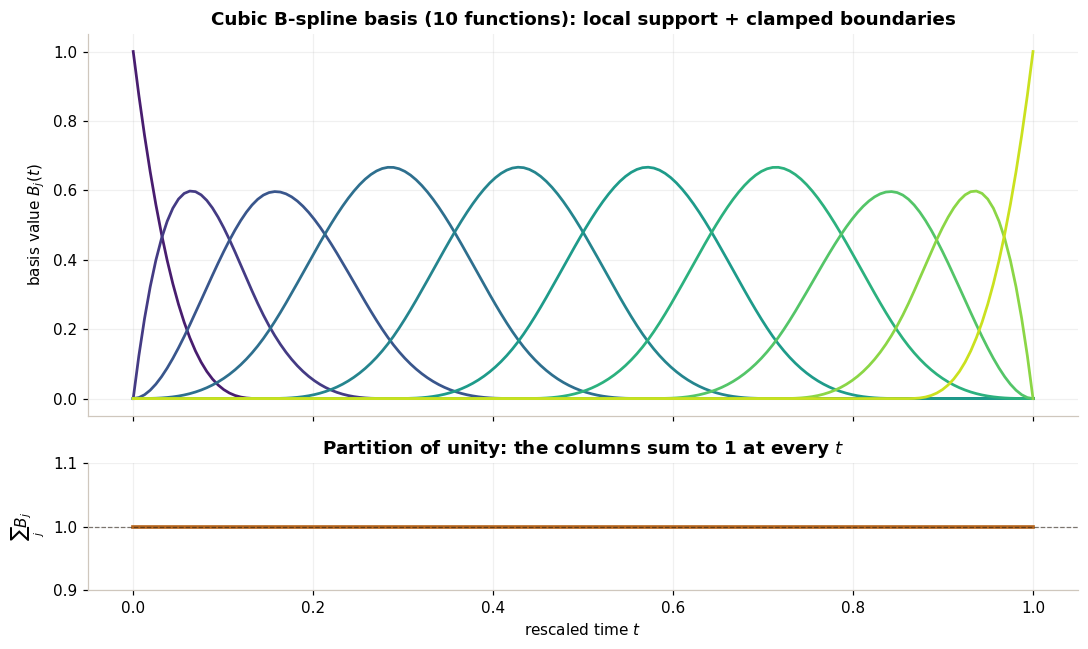

In [15]:
fig, (axb, axs) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
bcolors = plt.cm.viridis(np.linspace(0.08, 0.92, M))
for j in range(M):
    axb.plot(t, B[:, j], color=bcolors[j], lw=1.8)
axb.set_ylabel("basis value $B_j(t)$")
axb.set_title(f"Cubic B-spline basis ({M} functions): local support + clamped boundaries")

axs.plot(t, B.sum(axis=1), color=ACCENT, lw=2.4)
axs.axhline(1.0, color=INK, lw=0.8, ls="--", alpha=0.6)
axs.set_ylim(0.9, 1.1)
axs.set_xlabel("rescaled time $t$"); axs.set_ylabel(r"$\sum_j B_j$")
axs.set_title("Partition of unity: the columns sum to 1 at every $t$")
plt.tight_layout(); plt.show()

## Head-to-head: fitting all three families to one series

Now the payoff. We synthesize a single trending baseline with **two structural breaks** — a gentle
climb, a sharp acceleration partway through, then a flattening — plus noise. We fit each family by least
squares and compare:

- **Linear** $X=[\mathbf 1,\, t]$ — two parameters; *must* underfit the kinks.
- **Piecewise** $X=[\mathbf 1,\, t,\, A\!\cdot\! t,\, A]$ — the global line plus, per changepoint, a
  *slope-change* column $A_{\cdot j}\,t$ **and** its level-correction column $A_{\cdot j}$. Together these
  span the ramp basis $(t-s_j)_{+} = A_{\cdot j}\,t - s_j\,A_{\cdot j}$, so least squares recovers the
  continuous slope-change trend exactly (dropping the $A$ columns would force small jumps at each $s_j$).
- **B-spline** $X=B$ — the partition-of-unity basis (it carries its own intercept, so no extra column).

We expect the linear fit to miss the breaks badly, while both flexible families track them. The
assertions encode exactly that ordering: the flexible families beat the linear one. (We do *not* assert
the linear fit is good — by design it cannot be.)

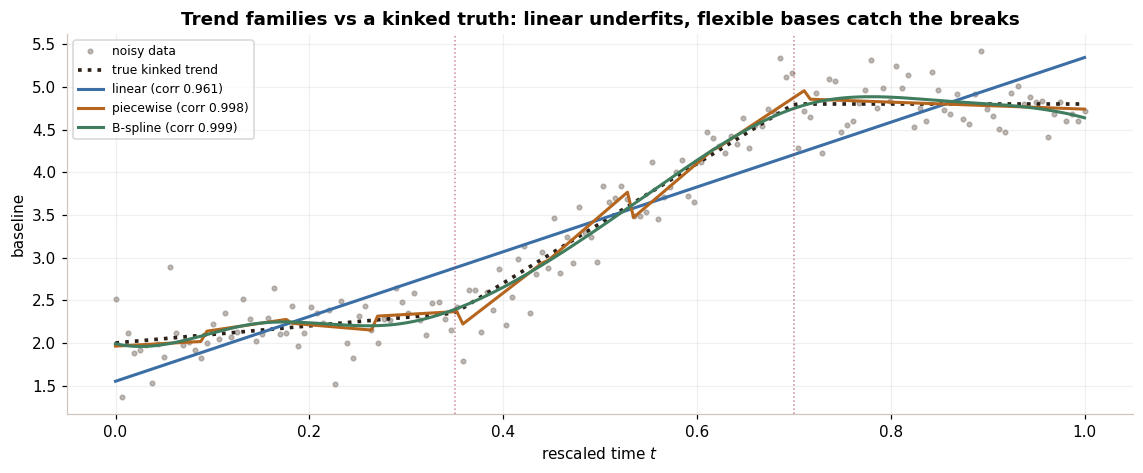

correlation with truth: {'linear': np.float64(0.9613), 'piecewise': np.float64(0.9983), 'bspline': np.float64(0.999)}


In [16]:
# Synthetic trending + kinked baseline (on the [0,1] axis), with noise.
def kinked_trend(t):
    base = 2.0 + 1.0 * t                       # gentle climb
    base += 6.0 * np.clip(t - 0.35, 0, None)   # acceleration after t=0.35
    base += -7.0 * np.clip(t - 0.70, 0, None)  # flattening/decline after t=0.70
    return base

rng = np.random.default_rng(3)
truth = kinked_trend(t)
y = truth + rng.normal(0, 0.25, size=N)

def lstsq_fit(X, target):
    coef, *_ = np.linalg.lstsq(X, target, rcond=None)
    return X @ coef

X_lin = np.column_stack([np.ones(N), t])
X_pw  = np.column_stack([np.ones(N), t, A * t[:, None], A])  # 1, base slope, slope-change ramps + level corr
X_bs  = B                                       # partition of unity already spans the constant

fit_linear = lstsq_fit(X_lin, y)
fit_piece  = lstsq_fit(X_pw,  y)
fit_spline = lstsq_fit(X_bs,  y)

corr = {
    "linear":    np.corrcoef(truth, fit_linear)[0, 1],
    "piecewise": np.corrcoef(truth, fit_piece)[0, 1],
    "bspline":   np.corrcoef(truth, fit_spline)[0, 1],
}

fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.plot(t, y, "o", ms=3, color=MUTED, alpha=0.55, label="noisy data")
ax.plot(t, truth, color=INK, lw=2.4, ls=":", label="true kinked trend")
ax.plot(t, fit_linear, color=PALETTE["sky"], lw=2,
        label=rf"linear (corr {corr['linear']:.3f})")
ax.plot(t, fit_piece, color=ACCENT, lw=2,
        label=rf"piecewise (corr {corr['piecewise']:.3f})")
ax.plot(t, fit_spline, color=PALETTE["leaf"], lw=2,
        label=rf"B-spline (corr {corr['bspline']:.3f})")
for cp in (0.35, 0.70):
    ax.axvline(cp, color=PALETTE["berry"], lw=1, ls=":", alpha=0.6)
ax.set_xlabel("rescaled time $t$"); ax.set_ylabel("baseline")
ax.set_title("Trend families vs a kinked truth: linear underfits, flexible bases catch the breaks")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print("correlation with truth:", {k: round(v, 4) for k, v in corr.items()})

In [17]:
# VERIFY the comparison: flexible families recover the kinked signal (high corr),
# and BOTH beat the linear fit, which underfits the breaks by construction.
assert corr["piecewise"] > 0.97, f"piecewise should track truth, corr={corr['piecewise']:.3f}"
assert corr["bspline"]   > 0.97, f"B-spline should track truth, corr={corr['bspline']:.3f}"
assert corr["piecewise"] > corr["linear"], "piecewise must beat linear on a kinked signal"
assert corr["bspline"]   > corr["linear"], "B-spline must beat linear on a kinked signal"
print(f"✓ piecewise corr {corr['piecewise']:.4f} > 0.97 and > linear {corr['linear']:.4f}")
print(f"✓ B-spline  corr {corr['bspline']:.4f} > 0.97 and > linear {corr['linear']:.4f}")
print("✓ flexible trend bases recover structural breaks the linear trend cannot.")

✓ piecewise corr 0.9983 > 0.97 and > linear 0.9613
✓ B-spline  corr 0.9990 > 0.97 and > linear 0.9613
✓ flexible trend bases recover structural breaks the linear trend cannot.


# Recap & what's next

**Seasonality (Part I).** Periodic baseline motion is a truncated Fourier series. `create_fourier_features`
builds a $(T, 2K)$ design matrix of **interleaved** $[\sin_k, \cos_k]$ harmonics; the sine/cosine pair at
each frequency buys arbitrary amplitude *and* phase. Order $K$ is a bias–variance dial — higher $K$
lowers the in-sample residual but risks chasing noise, so the framework couples a modest order with a
shrinking $\mathcal{N}(0, 0.3)$ prior on the coefficients.

**Trend (Part II).** Non-periodic drift is a basis expansion of choosable flexibility:

| Family | Design $X$ | Coefficients / prior | Bends? |
|---|---|---|---|
| Linear (default) | $[\mathbf 1,\, t]$ | `trend_slope` $\sim \mathcal{N}(0, 0.5)$ | no |
| Piecewise (Prophet) | $[\mathbf 1,\, t,\, A\!\cdot\! t,\, A]$, $A_{t,j}=\mathbf 1[t\ge s_j]$ | sparse slope changes $\boldsymbol\delta$ (Laplace) | slope kinks at changepoints |
| B-spline | $B$ (partition of unity, clamped) | $\mathcal{N}$ w/ $\text{HalfNormal}$ scale | smoothly |
| GP / Hilbert-space | — (nonparametric) | covariance hyper-priors | fully flexible |

**The unifying pattern.** Every component here follows the same recipe — a fixed basis matrix $\Phi$
encoding the *shape*, multiplied by learned coefficients whose *amplitude* is controlled by a
regularizing prior. Get the basis right and the prior does the rest.

**The two things people get wrong:**
1. Fourier columns are **interleaved** $[\sin_1, \cos_1, \sin_2, \cos_2, \dots]$ and **zero-mean** — they
   carry no constant, so the baseline level is a separate intercept.
2. The trend functions assume a **rescaled** axis $t \in [0,1]$; the piecewise changepoints only populate
   the first 80% of it. Feeding raw week numbers degenerates both bases.
3. `create_piecewise_trend_matrix` returns the **step** indicator $A_{t,j}=\mathbf 1[t\ge s_j]$, but the
   Prophet trend uses it to change the **slope**, not the level: each $\delta_j$ multiplies $t$ via
   $(k+A\boldsymbol\delta)\,t$, and the offset correction $\gamma_j=-s_j\delta_j$ keeps the trend
   **continuous** (the ramp basis $(t-s_j)_{+}$). Dropping the $\cdot\,t$ — adding $A\boldsymbol\delta$ as a
   bare term — would give piecewise-*constant* level shifts; that was a bug, now fixed in `base.py`'s
   `_build_piecewise_trend`. The lone $\boldsymbol\gamma$ continuity term is the tell that slope changes,
   not level shifts, were always intended.

**Where this fits in the math series:**
- **`math_01_adstock.ipynb`** — carryover, the first media transform; shares the *normalized-basis* idea
  with the B-spline partition of unity.
- **`math_02_saturation.ipynb`** — diminishing returns, the media nonlinearity.
- **`math_04_*.ipynb`** — assembling baseline (this notebook) + media response into the full additive
  decomposition and contribution accounting.